In [5]:
!pip install -q "transformers>=4.37.0" accelerate sentencepiece protobuf flash-attn --no-build-isolation

In [6]:
import transformers
print(f"Transformers version: {transformers.__version__}")

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Transformers version: 5.2.0
PyTorch: 2.9.0+cu126
CUDA available: True
GPU: NVIDIA H100 80GB HBM3


In [7]:
import os, re, time, json
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

# Config
MODEL_NAME     = "meta-llama/Meta-Llama-3.1-8B-Instruct"
OUTPUT_DIR     = "/kaggle/working/llama3_1_gsm8k"
os.makedirs(OUTPUT_DIR, exist_ok=True)
MAX_SAMPLES    = 500
MAX_NEW_TOKENS = 512
EVAL_BATCH_SIZE = 64
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")
print(f"Model : {MODEL_NAME}")

Device: cuda
Model : meta-llama/Meta-Llama-3.1-8B-Instruct


In [8]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)
print("Logged in to Hugging Face.")

Logged in to Hugging Face.


In [9]:
from datasets import load_dataset

ds = load_dataset("gsm8k", "main", split="test")
df = ds.to_pandas()[["question", "answer"]].rename(
    columns={"question": "Question", "answer": "Answer"}
).head(MAX_SAMPLES).reset_index(drop=True)

print(f"Loaded {len(df)} GSM8K questions")
print(df.iloc[0]["Answer"][-30:])


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Loaded 500 GSM8K questions
t the farmer’s market.
#### 18


In [10]:
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True, padding_side='left')

# Llama 3 does not have a dedicated pad token — use eos token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print("Loading model in bfloat16 (H100 has 80GB, no quantization needed)...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="flash_attention_2",
)
model.eval()
model = torch.compile(model, mode="reduce-overhead")
print(f"Model on: {next(model.parameters()).device}")

Loading tokenizer...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Model on: cuda:0


In [11]:
def extract_answer(text, is_gt=False):
    text = str(text)
    if is_gt:
        match = re.search(r"####\s*([\d,\.\-]+)", text)
        return match.group(1).replace(",", "").strip() if match else text.strip()
    match = re.search(r"####\s*([\d,\.\-]+)", text)
    if match:
        return match.group(1).replace(",", "").strip()
    idx = text.find("\\boxed{")
    if idx != -1:
        depth, start, end = 1, idx + 7, idx + 7
        while end < len(text) and depth > 0:
            if text[end] == "{": depth += 1
            elif text[end] == "}": depth -= 1
            end += 1
        if depth == 0:
            return text[start:end-1].strip()
    numbers = re.findall(r"[\-]?[\d,]+\.?\d*", text)
    return numbers[-1].replace(",", "") if numbers else text.strip()

def normalize(ans):
    return re.sub(r"[^\w.+\-/]", "", str(ans).strip().replace(",", "").lower())

def is_correct(pred, gt):
    p = normalize(extract_answer(pred, is_gt=False))
    g = normalize(extract_answer(gt,   is_gt=True))
    if p == g: return True
    try:
        return abs(float(p) - float(g)) < 1e-6
    except:
        return False


In [12]:
# Prompts from the TokenSkip paper
PROMPTS = {
    "Original":    "Solve the following math problem step by step.\n\nProblem: {question}\n\nSolution:",
    "BeConcise":   "Be concise. Solve the following math problem step by step.\n\nProblem: {question}\n\nSolution:",
    "OnlyNumbers": "Only use numbers or equations. Solve the following math problem step by step.\n\nProblem: {question}\n\nSolution:",
    "AbbreWords":  "Abbreviate words as much as possible. Solve the following math problem step by step.\n\nProblem: {question}\n\nSolution:",
}

def make_prompt(question, method):
    prompt = PROMPTS[method].format(question=question)
    messages = [{"role": "user", "content": prompt}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


In [13]:
def evaluate_batched(df, method="Original", max_new_tokens=MAX_NEW_TOKENS, original_avg_tokens=None):
    all_responses    = []
    all_token_counts = []
    start_time       = time.time()

    # Sort by prompt length to minimise padding waste within batches
    prompts_indexed = [(i, make_prompt(row['Question'], method)) for i, row in df.iterrows()]
    prompts_indexed.sort(key=lambda x: len(x[1]))
    sorted_indices = [i for i, _ in prompts_indexed]
    prompts        = [p for _, p in prompts_indexed]

    for batch_start in tqdm(range(0, len(prompts), EVAL_BATCH_SIZE),
                             desc=f"{method} (bs={EVAL_BATCH_SIZE})"):
        batch_prompts = prompts[batch_start:batch_start + EVAL_BATCH_SIZE]

        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=2048
        ).to(DEVICE)

        input_len = inputs['input_ids'].shape[1]

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        generated   = outputs[:, input_len:]
        token_counts = (generated != tokenizer.pad_token_id).sum(dim=1).tolist()
        all_token_counts.extend(token_counts)

        responses = tokenizer.batch_decode(generated, skip_special_tokens=True)
        all_responses.extend(responses)

        del outputs, inputs, generated
        torch.cuda.empty_cache()

    # Restore original row order so responses align with df
    reordered_responses    = [None] * len(df)
    reordered_token_counts = [None] * len(df)
    for sorted_pos, orig_idx in enumerate(sorted_indices):
        reordered_responses[orig_idx]    = all_responses[sorted_pos]
        reordered_token_counts[orig_idx] = all_token_counts[sorted_pos]

    elapsed    = time.time() - start_time
    correct    = sum(is_correct(r, g) for r, g in zip(reordered_responses, df['Answer']))
    avg_tokens = sum(reordered_token_counts) / len(df)

    return {
        'Method':     method,
        'Accuracy':   round(100 * correct / len(df), 2),
        'Avg Tokens': round(avg_tokens, 2),
        'Latency(s)': round(elapsed / len(df), 3),
        'Act Ratio':  round(avg_tokens / original_avg_tokens if original_avg_tokens else 1.0, 3),
        'Correct':    correct,
        'Total':      len(df),
    }, reordered_responses, reordered_token_counts

In [14]:
all_results           = []
all_responses_dict    = {}
all_token_counts_dict = {}
checkpoint_path       = f"{OUTPUT_DIR}/checkpoint.json"

if os.path.exists(checkpoint_path):
    with open(checkpoint_path) as f:
        checkpoint = json.load(f)
    all_results       = checkpoint.get('results', [])
    completed_methods = {r['Method'] for r in all_results}
    print(f"Resuming: {completed_methods} already done")
else:
    completed_methods = set()

eval_start = time.time()

for method in ["Original", "BeConcise", "OnlyNumbers", "AbbreWords"]:
    if method in completed_methods:
        print(f"Skipping {method} (already done)")
        continue

    print(f"\n{'='*60}\nEvaluating: {method}\n{'='*60}")
    orig_tokens = next((r['Avg Tokens'] for r in all_results if r['Method'] == 'Original'), None)

    result, responses, token_counts = evaluate_batched(df, method=method, original_avg_tokens=orig_tokens)
    all_results.append(result)
    all_responses_dict[method]    = responses
    all_token_counts_dict[method] = token_counts
    print(f"{method}: {result['Accuracy']:.1f}% acc | {result['Avg Tokens']:.1f} tokens | {result['Latency(s)']:.2f}s/sample")

    with open(checkpoint_path, 'w') as f:
        json.dump({'results': all_results}, f)

orig_tokens = next(r['Avg Tokens'] for r in all_results if r['Method'] == 'Original')

for ratio in [0.9, 0.8, 0.7, 0.6, 0.5]:
    method_key = f"Truncation_{ratio}"
    if method_key in completed_methods:
        print(f"Skipping {method_key} (already done)")
        continue

    print(f"\n{'='*60}\nEvaluating: Truncation ratio={ratio}\n{'='*60}")
    max_tok = int(MAX_NEW_TOKENS * ratio)

    result, responses, token_counts = evaluate_batched(df, method="Original", max_new_tokens=max_tok, original_avg_tokens=orig_tokens)
    result['Method'] = method_key
    result['Ratio']  = ratio
    all_results.append(result)
    all_responses_dict[method_key]    = responses
    all_token_counts_dict[method_key] = token_counts
    print(f"Truncation {ratio}: {result['Accuracy']:.1f}% acc | {result['Avg Tokens']:.1f} tokens")

    with open(checkpoint_path, 'w') as f:
        json.dump({'results': all_results}, f)

total_time = time.time() - eval_start
print(f"\nAll evaluations complete in {total_time/3600:.2f} hours")


Evaluating: Original


Original (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Original: 78.6% acc | 244.5 tokens | 0.30s/sample

Evaluating: BeConcise


BeConcise (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

...

Truncation 0.7: 75.8% acc | 238.8 tokens

Evaluating: Truncation ratio=0.6


Original (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

Truncation 0.6: 69.0% acc | 232.4 tokens

Evaluating: Truncation ratio=0.5


Original (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

Truncation 0.5: 57.0% acc | 219.2 tokens

All evaluations complete in 0.29 hours


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

final_df = pd.DataFrame(all_results)

orig_tokens = final_df[final_df['Method'] == 'Original']['Avg Tokens'].values[0]
orig_acc    = final_df[final_df['Method'] == 'Original']['Accuracy'].values[0]

final_df['Token Savings (%)'] = ((1 - final_df['Avg Tokens'] / orig_tokens) * 100).round(2)
final_df['Accuracy Drop']     = (orig_acc - final_df['Accuracy']).round(2)
final_df['Efficiency Score']  = (final_df['Accuracy'] / final_df['Avg Tokens'] * 100).round(3)

final_df.to_csv(f"{OUTPUT_DIR}/results.csv", index=False)

print("=" * 70)
print("TOKENSKIP FULL RESULTS — GSM8K (500 samples) — Llama-3.1-8B-Instruct")
print("=" * 70)
print(final_df[['Method', 'Accuracy', 'Avg Tokens', 'Token Savings (%)',
                 'Accuracy Drop', 'Act Ratio', 'Latency(s)']].to_string(index=False))
print("=" * 70)

ranked = final_df[['Method', 'Accuracy', 'Avg Tokens', 'Token Savings (%)',
                    'Efficiency Score']].sort_values('Efficiency Score', ascending=False)
print("\nEFFICIENCY RANKING")
print(ranked.to_string(index=False))

best_eff     = final_df[final_df['Method'] != 'Original'].sort_values('Efficiency Score', ascending=False).iloc[0]
most_savings = final_df.sort_values('Token Savings (%)', ascending=False).iloc[0]
best_acc     = final_df.sort_values('Accuracy', ascending=False).iloc[0]

print("\nKEY FINDINGS")
print("=" * 70)
print(f"Best Efficiency Method : {best_eff['Method']} (score={best_eff['Efficiency Score']:.3f})")
print(f"Most Token Savings     : {most_savings['Method']} ({most_savings['Token Savings (%)']:.1f}% saved)")
print(f"Best Accuracy          : {best_acc['Method']} ({best_acc['Accuracy']:.1f}%)")
print(f"Baseline (Original)    : {orig_acc:.1f}% acc, {orig_tokens:.0f} avg tokens")

TOKENSKIP FULL RESULTS — GSM8K (500 samples) — Llama-3.1-8B-Instruct
        Method  Accuracy  Avg Tokens  Token Savings (%)  Accuracy Drop  Act Ratio  Latency(s)
      Original      78.6      244.52               0.00            0.0      1.000       0.302
     BeConcise      82.4      170.10              30.44           -3.8      0.696       0.235
   OnlyNumbers      80.4      114.54              53.16           -1.8      0.468       0.214
    AbbreWords      79.2      145.02              40.69           -0.6      0.593       0.275
Truncation_0.9      78.6      243.54               0.40            0.0      0.996       0.271
Truncation_0.8      77.6      241.76               1.13            1.0      0.989       0.244
Truncation_0.7      75.8      238.81               2.34            2.8      0.977       0.214
Truncation_0.6      69.0      232.37               4.97            9.6      0.950       0.186
Truncation_0.5      57.0      219.15              10.38           21.6      0.896    

In [17]:
tradeoff = final_df[['Method', 'Accuracy', 'Token Savings (%)', 'Accuracy Drop']].copy()
tradeoff['Acc Drop per 10% Savings'] = (
    tradeoff['Accuracy Drop'] / (tradeoff['Token Savings (%)'] / 10)
).round(3)
tradeoff.loc[tradeoff['Token Savings (%)'] <= 0, 'Acc Drop per 10% Savings'] = 0.0

print("ACCURACY-EFFICIENCY TRADEOFF")
print("(How much accuracy is lost per 10% token savings)")
print("=" * 70)
print(tradeoff.to_string(index=False))

ACCURACY-EFFICIENCY TRADEOFF
(How much accuracy is lost per 10% token savings)
        Method  Accuracy  Token Savings (%)  Accuracy Drop  Acc Drop per 10% Savings
      Original      78.6               0.00            0.0                     0.000
     BeConcise      82.4              30.44           -3.8                    -1.248
   OnlyNumbers      80.4              53.16           -1.8                    -0.339
    AbbreWords      79.2              40.69           -0.6                    -0.147
Truncation_0.9      78.6               0.40            0.0                     0.000
Truncation_0.8      77.6               1.13            1.0                     8.850
Truncation_0.7      75.8               2.34            2.8                    11.966
Truncation_0.6      69.0               4.97            9.6                    19.316
Truncation_0.5      57.0              10.38           21.6                    20.809


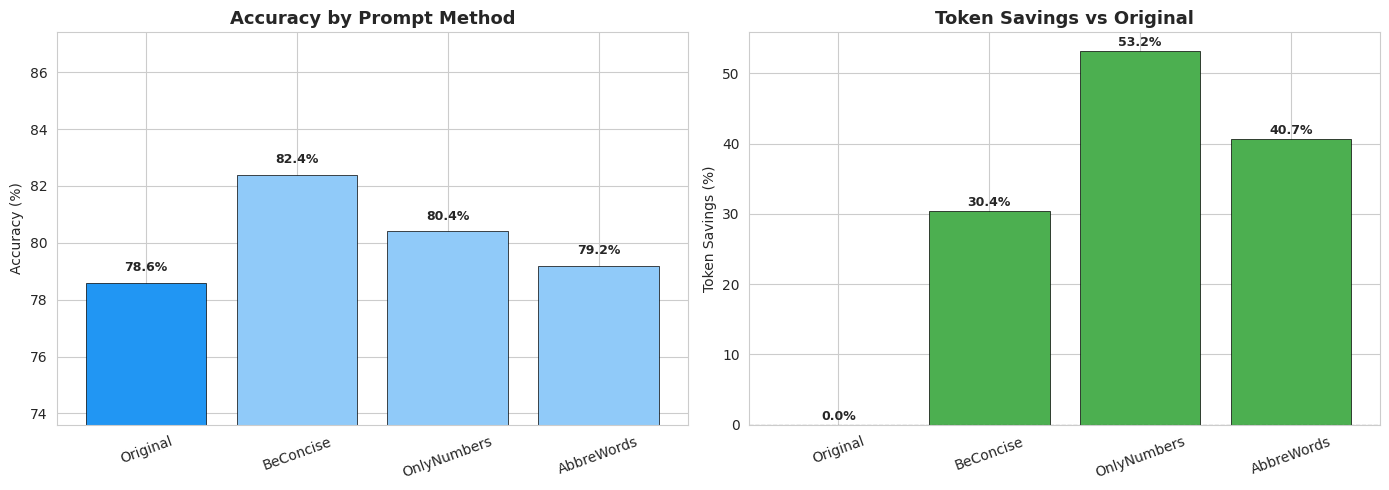

In [18]:
prompt_df = final_df[~final_df['Method'].str.contains("Truncation")].copy()

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3' if m == 'Original' else '#90CAF9' for m in prompt_df['Method']]
bars = axes[0].bar(prompt_df['Method'], prompt_df['Accuracy'],
                    color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title("Accuracy by Prompt Method", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(prompt_df['Accuracy'].min() - 5, prompt_df['Accuracy'].max() + 5)
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, prompt_df['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

colors2 = ['#4CAF50' if s > 0 else '#F44336' for s in prompt_df['Token Savings (%)']]
bars2 = axes[1].bar(prompt_df['Method'], prompt_df['Token Savings (%)'],
                     color=colors2, edgecolor='black', linewidth=0.5)
axes[1].set_title("Token Savings vs Original", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Token Savings (%)")
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars2, prompt_df['Token Savings (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("/kaggle/working/llama_prompt_methods.png", dpi=300, bbox_inches='tight')
plt.show()

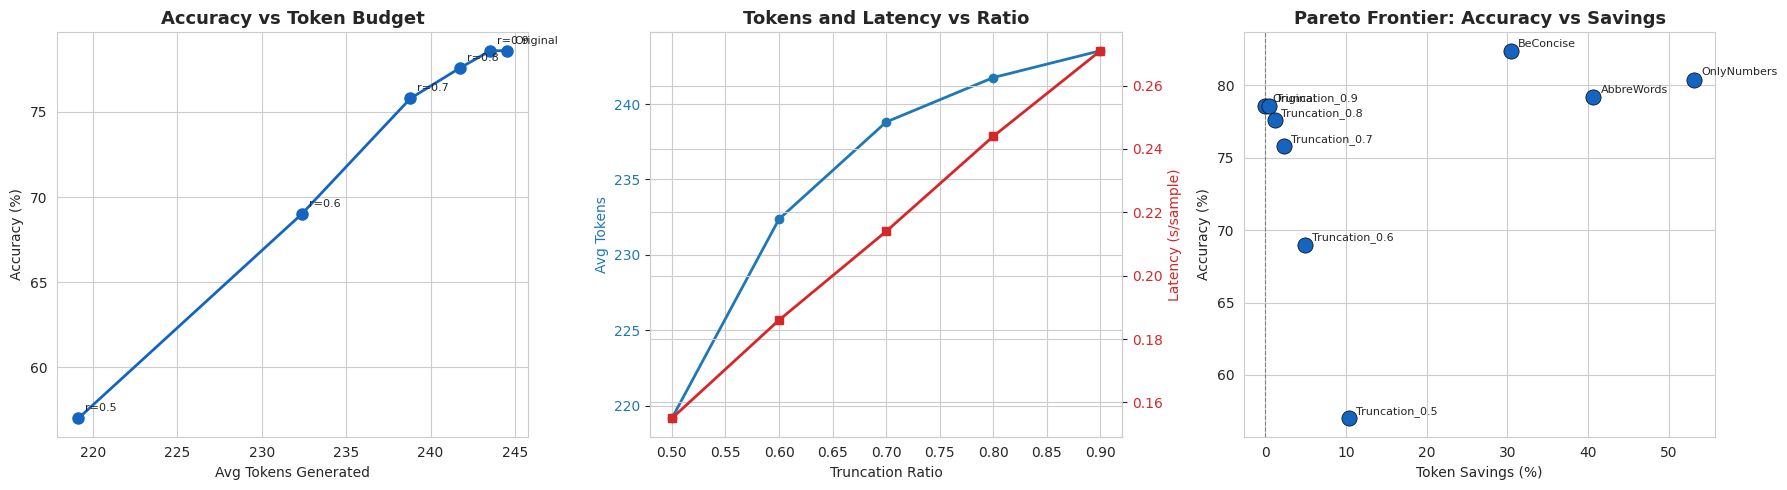

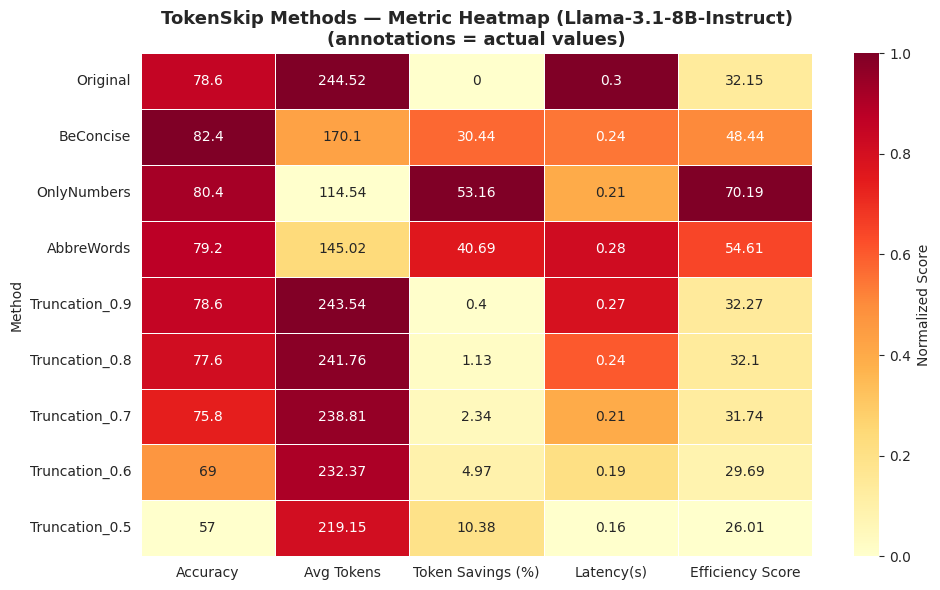

In [19]:
trunc_df = final_df[final_df['Method'].str.contains("Truncation")].copy().sort_values('Ratio')
trunc_with_orig = pd.concat([
    final_df[final_df['Method'] == 'Original'],
    trunc_df
]).sort_values('Avg Tokens')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(trunc_with_orig['Avg Tokens'], trunc_with_orig['Accuracy'],
             'o-', color='#1565C0', linewidth=2, markersize=8)
for _, row in trunc_with_orig.iterrows():
    label = f"r={row['Ratio']}" if pd.notna(row.get('Ratio')) else 'Original'
    axes[0].annotate(label, (row['Avg Tokens'], row['Accuracy']),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[0].set_xlabel("Avg Tokens Generated")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Accuracy vs Token Budget", fontsize=13, fontweight='bold')

ax1 = axes[1]
ax2 = ax1.twinx()
ax1.plot(trunc_df['Ratio'], trunc_df['Avg Tokens'], 'o-', color='tab:blue', linewidth=2)
ax2.plot(trunc_df['Ratio'], trunc_df['Latency(s)'], 's-', color='tab:red', linewidth=2)
ax1.set_xlabel("Truncation Ratio")
ax1.set_ylabel("Avg Tokens", color='tab:blue')
ax2.set_ylabel("Latency (s/sample)", color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
axes[1].set_title("Tokens and Latency vs Ratio", fontsize=13, fontweight='bold')

axes[2].scatter(final_df['Token Savings (%)'], final_df['Accuracy'],
                s=120, c='#1565C0', zorder=5, edgecolors='black', linewidth=0.5)
for _, row in final_df.iterrows():
    axes[2].annotate(row['Method'], (row['Token Savings (%)'], row['Accuracy']),
                     textcoords="offset points", xytext=(5, 3), fontsize=8)
axes[2].set_xlabel("Token Savings (%)")
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_title("Pareto Frontier: Accuracy vs Savings", fontsize=13, fontweight='bold')
axes[2].axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig("/kaggle/working/llama_truncation_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

# Heatmap
pivot = final_df[['Method', 'Accuracy', 'Avg Tokens', 'Token Savings (%)',
                   'Latency(s)', 'Efficiency Score']].set_index('Method')
pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min())

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_norm, annot=pivot.round(2), fmt='g', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized Score'})
ax.set_title("TokenSkip Methods — Metric Heatmap (Llama-3.1-8B-Instruct)\n(annotations = actual values)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/llama_method_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# GSM8K has no level/subject metadata
print(f"All outputs saved to: {OUTPUT_DIR}")


All outputs saved to: /kaggle/working/llama3_1_gsm8k


In [21]:
original_responses = all_responses_dict.get("Original", [])
df["Predicted"] = original_responses
df["Correct"]   = [is_correct(p, g) for p, g in zip(original_responses, df["Answer"])]
print(f"Original accuracy: {df['Correct'].mean()*100:.2f}%")
print(f"Correct: {df['Correct'].sum()} / {len(df)}")


Original accuracy: 78.60%
Correct: 393 / 500


In [22]:
# No level/subject breakdown for GSM8K
print("Skipping - not available for GSM8K")


Skipping - not available for GSM8K


/tmp/ipykernel_106/1817700120.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=token_dist_df, x='Method', y='Tokens', palette='Blues', ax=ax)


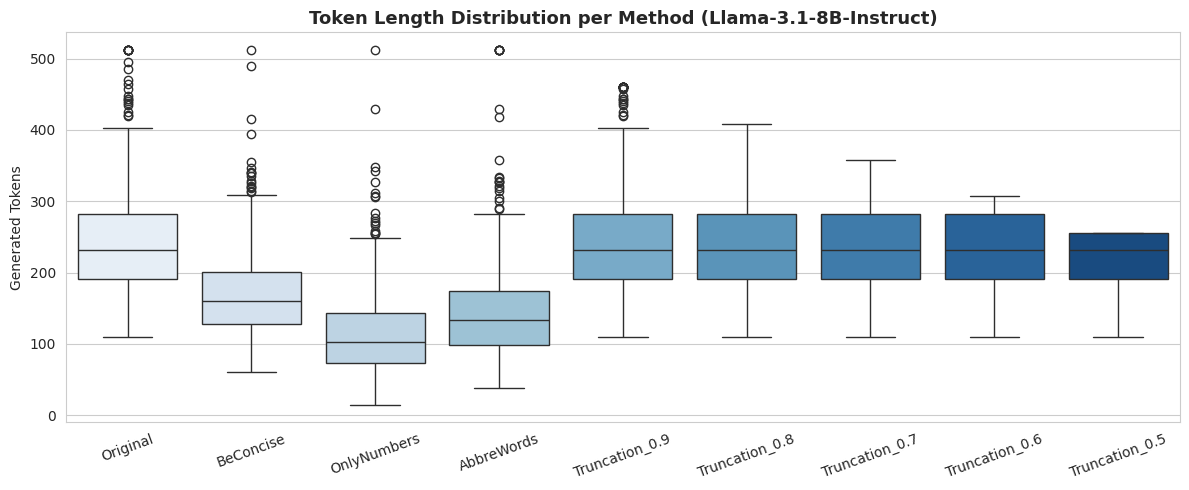

In [23]:
token_dist_data = []
for method, counts in all_token_counts_dict.items():
    for count in counts:
        token_dist_data.append({'Method': method, 'Tokens': count})

token_dist_df = pd.DataFrame(token_dist_data)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=token_dist_df, x='Method', y='Tokens', palette='Blues', ax=ax)
ax.set_title("Token Length Distribution per Method (Llama-3.1-8B-Instruct)", fontsize=13, fontweight='bold')
ax.set_xlabel("")
ax.set_ylabel("Generated Tokens")
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig("/kaggle/working/llama_token_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [25]:
import shutil
shutil.make_archive("/kaggle/working/llama3_1_gsm8k", "zip", OUTPUT_DIR)

'/kaggle/working/llama3_1_gsm8k.zip'